✅ AZN.txt: loaded 5119 rows. DEPTH col idx=0, GR col idx=4 (using curve: GR)


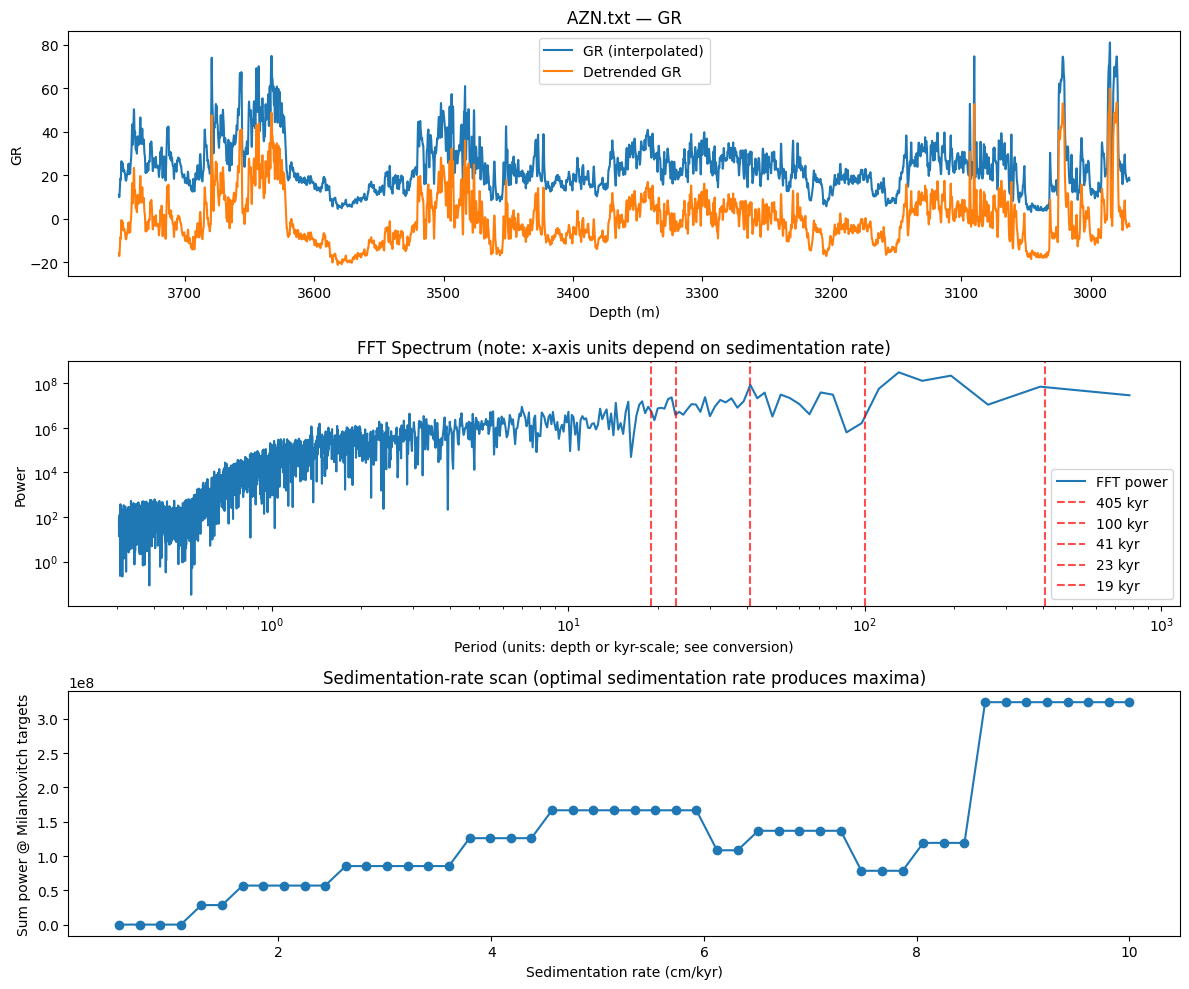

✅ YRN.txt: loaded 4994 rows. DEPTH col idx=0, GR col idx=15 (using curve: GR)


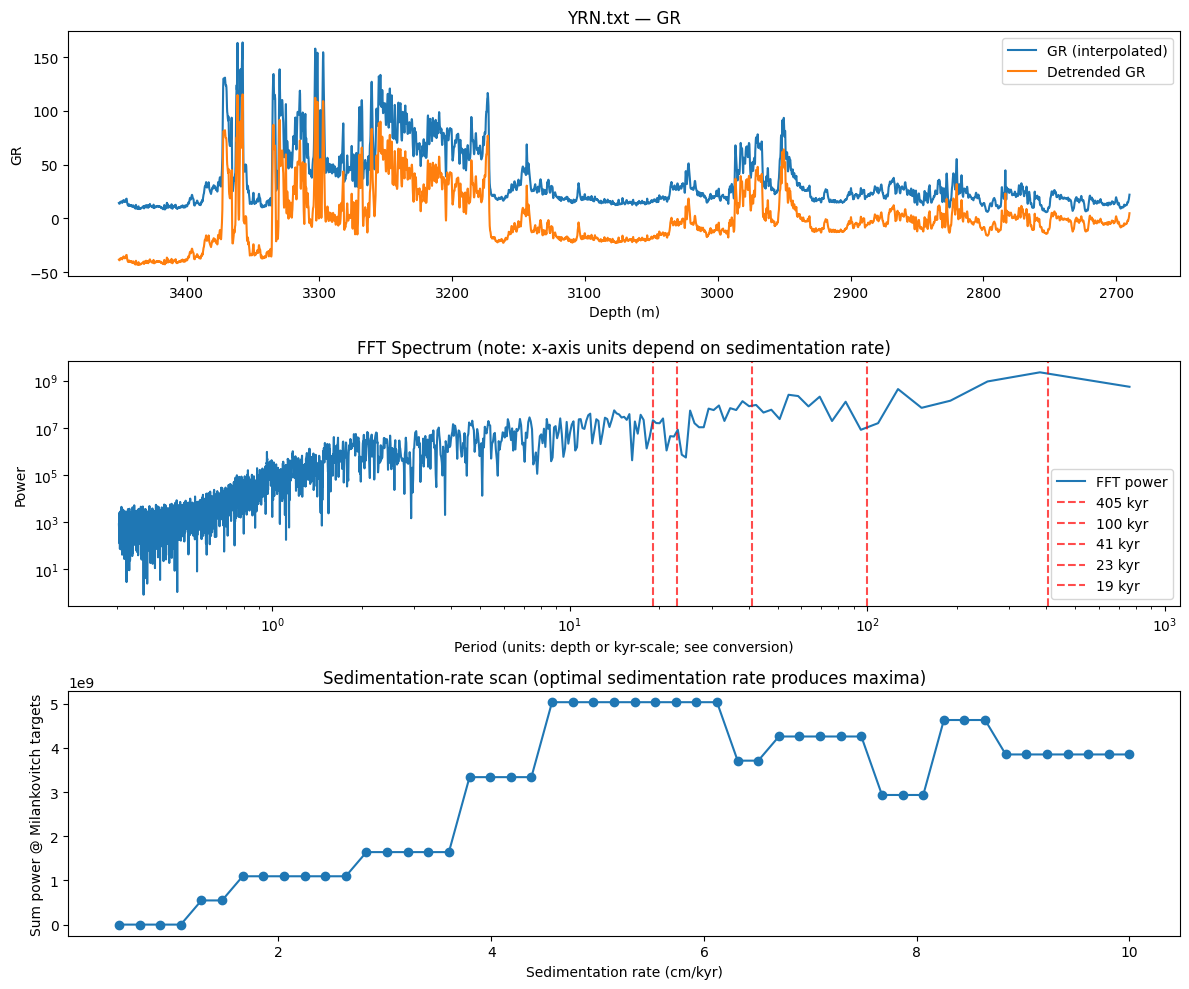

✅ JF.txt: loaded 5321 rows. DEPTH col idx=0, GR col idx=1 (using curve: GR)


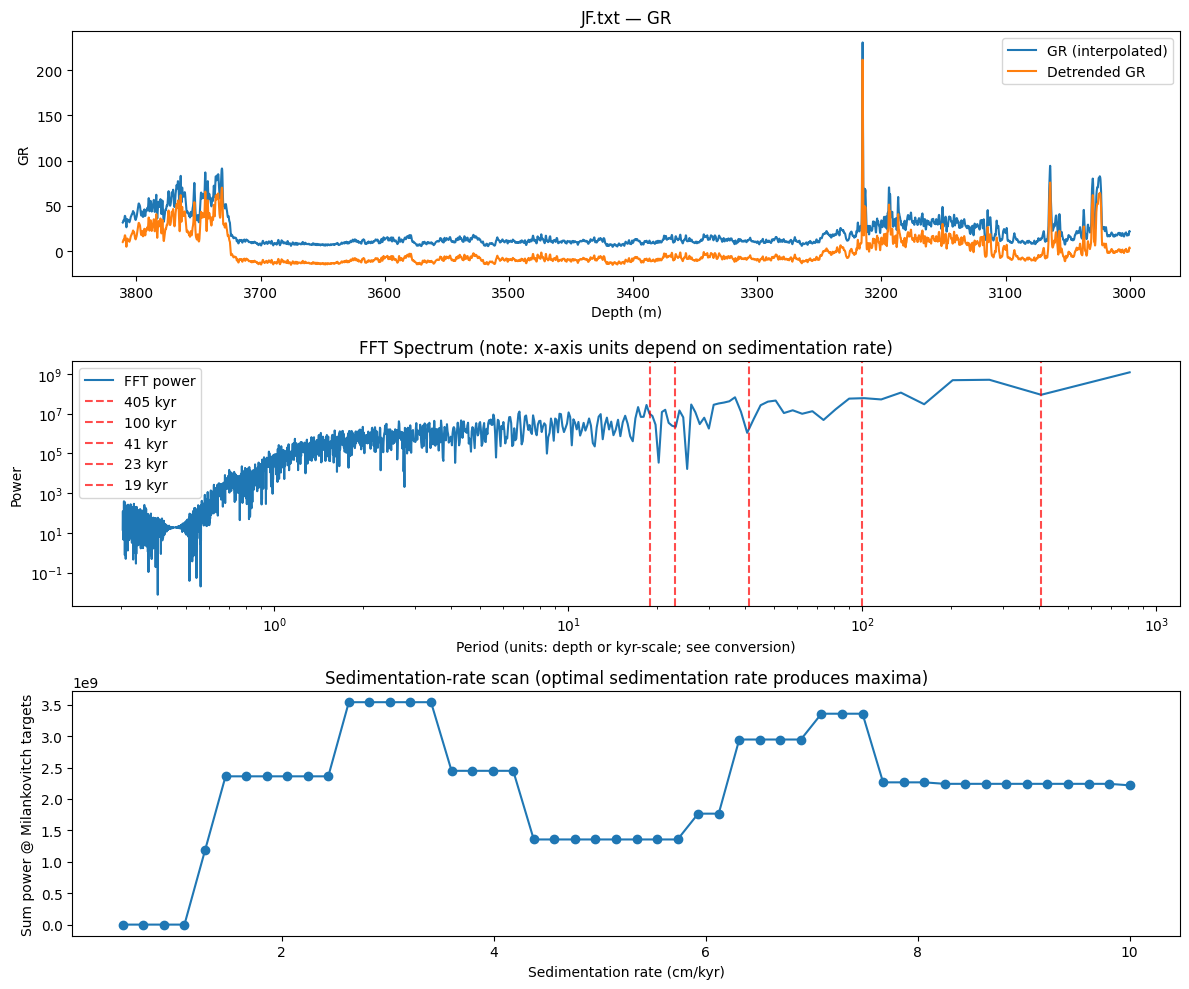

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, interpolate
from scipy.signal import lombscargle
import sys

# --------------------------
# Helper: parse header then load numeric block
# --------------------------
def parse_header_and_start(file_path):
    """
    Return (header_names_list, data_start_line_index)
    header_names_list: ordered list of mnemonic strings (may contain spaces)
    data_start_line_index: integer (0-based) index of first numeric line
    """
    header_names = []
    data_start = None
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # iterate lines, pull header entries and detect numeric start
    for i, line in enumerate(lines):
        s = line.rstrip("\n")
        stripped = s.strip()

        # detect the first numeric data line (starts with a number -> depth)
        # allow leading minus and decimal
        first_token = (stripped.split()[0] if stripped.split() else "")
        is_numeric = False
        if first_token:
            try:
                float(first_token)
                is_numeric = True
            except Exception:
                is_numeric = False

        # If numeric found, stop and mark data start
        if is_numeric:
            data_start = i
            break

        # Candidate header lines often contain a dot '.' (units) and a colon ':'
        # e.g. "GR .gAPI : GR"
        # Also accept lines that look like "DEPTH                    .M :"
        if "." in s and ":" in s and not stripped.startswith("#"):
            # take text before the first dot as mnemonic
            mnemonic = s.split(".", 1)[0].strip()
            if mnemonic:
                header_names.append(mnemonic)
            continue

        # Some files may list curve names without dot/colon; detect common pattern
        # e.g. lines that are all-uppercase short names
        if re.match(r"^\s*[A-Za-z0-9\-\_ ]{1,40}\s*$", s) and s.strip().isupper():
            header_names.append(s.strip())
            continue

        # ignore comment lines, blank lines, separators
        # continue scanning

    return header_names, data_start

# --------------------------
# Loader using header mapping + numeric fallback
# --------------------------
def load_well(file_path):
    """
    Load LAS-like text file and return DataFrame with columns DEPTH and GR (actual).
    Raises on failure.
    """
    header_names, data_start = parse_header_and_start(file_path)

    if data_start is None:
        raise ValueError(f"{file_path}: no numeric data found in file.")

    # read numeric block only
    df_num = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        skiprows=data_start,
        na_values=[-999.25, -999.250000],
        engine="python",
        comment=None,
    )

    # sanitize: convert to float where possible
    df_num = df_num.apply(pd.to_numeric, errors="coerce")

    # decide DEPTH index
    depth_idx = None
    # try to find DEPTH name in header if available
    for i, h in enumerate(header_names):
        if h is None:
            continue
        n = re.sub(r"\s+", " ", h).strip().upper()
        if n in ("DEPTH", "DEPT", "DEPT."):
            depth_idx = i
            break
    if depth_idx is None:
        # fallback to first column
        depth_idx = 0

    # decide GR index by header if possible
    gr_idx = None
    used_curve_name = None
    for i, h in enumerate(header_names):
        if h is None:
            continue
        n = re.sub(r"\s+", " ", h).strip().upper()
        # exact matches first
        if n == "GR":
            gr_idx = i; used_curve_name = "GR"; break
    # if exact GR not found, try CGR, SGR, GR_UNI, CGR_UNI etc.
    if gr_idx is None:
        for preferred in ("CGR","SGR","GR_UNI","CGR_UNI","SGR_UNI","GRKT","GKUT"):
            for i,h in enumerate(header_names):
                if h is None: continue
                n = re.sub(r"\s+", " ", h).strip().upper()
                if n == preferred:
                    gr_idx = i; used_curve_name = n; break
            if gr_idx is not None:
                break

    # If we have a header-based gr_idx ensure it's within df_num columns
    if gr_idx is not None and gr_idx >= df_num.shape[1]:
        # header guessed index but numeric block shorter -> ignore header-based index
        gr_idx = None
        used_curve_name = None

    # If header mapping fails or index out of range, try numeric heuristic:
    if gr_idx is None:
        # choose a numeric column (excluding depth_idx) that looks like gamma-ray:
        # median within broad GR-like bounds and with some variability
        candidates = []
        for j in range(df_num.shape[1]):
            if j == depth_idx:
                continue
            col = df_num.iloc[:, j].dropna()
            if len(col) < 10:
                continue
            med = float(np.nanmedian(col))
            std = float(np.nanstd(col))
            mn = float(np.nanmin(col))
            mx = float(np.nanmax(col))
            # typical GR values are positive and often within 0-200 or so.
            # allow a broad window
            if -50 <= med <= 1000 and std > 0.05:
                candidates.append((j, std, med, mn, mx))

        if candidates:
            # pick column with largest std (most variable -> likely a log)
            candidates.sort(key=lambda t: t[1], reverse=True)
            gr_idx = int(candidates[0][0])
            used_curve_name = f"COL_{gr_idx}"
        else:
            raise ValueError(f"{file_path}: Could not auto-detect GR-like column (no header match and heuristic failed).")

    # Now extract DEPTH and GR columns
    if depth_idx >= df_num.shape[1] or gr_idx >= df_num.shape[1]:
        raise ValueError(f"{file_path}: computed column indices out of range (depth {depth_idx}, gr {gr_idx}, available {df_num.shape[1]})")

    df_out = df_num.iloc[:, [depth_idx, gr_idx]].copy()
    df_out.columns = ["DEPTH", "GR"]
    # Drop rows with NaN in DEPTH or GR
    df_out = df_out.dropna(subset=["DEPTH", "GR"]).reset_index(drop=True)

    # store which curve name was used (if header present)
    if used_curve_name is None and header_names and gr_idx < len(header_names):
        used_curve_name = header_names[gr_idx]
    elif used_curve_name is None:
        used_curve_name = f"COL_{gr_idx}"

    print(f"✅ {file_path}: loaded {len(df_out)} rows. DEPTH col idx={depth_idx}, GR col idx={gr_idx} (using curve: {used_curve_name})")
    return df_out, used_curve_name

# --------------------------
# Spectral analysis & plotting (actual GR)
# --------------------------
def spectral_analysis_and_plot(df, curve_name="GR", file_label="Well Data", save_png=False):
    x = df["DEPTH"].values
    gr = df["GR"].values

    # Interpolate to uniform depth
    depth_uniform = np.linspace(x.min(), x.max(), len(x))
    interp_func = interpolate.interp1d(x, gr, kind="linear", fill_value="extrapolate")
    gr_uniform = interp_func(depth_uniform)

    # Replace invalids with mean
    mean_val = np.nanmean(gr_uniform)
    gr_uniform = np.nan_to_num(gr_uniform, nan=mean_val, posinf=mean_val, neginf=mean_val)

    # Detrend (actual GR)
    gr_detrended = signal.detrend(gr_uniform)

    # FFT
    n = len(gr_detrended)
    if n < 4:
        raise ValueError(f"{file_label}: too few samples ({n}) for FFT.")
    dx = depth_uniform[1] - depth_uniform[0]
    fft_vals = np.fft.rfft(gr_detrended)
    fft_freq = np.fft.rfftfreq(n, d=dx)   # cycles per meter (or per depth unit)
    fft_power = np.abs(fft_vals) ** 2

    # Lomb-Scargle (scipy implementation requires angular freqs)
    # choose frequency range (cycles per depth unit)
    freq_min = 1e-4
    freq_max = 0.02
    freqs = np.linspace(freq_min, freq_max, 2000)
    ang_freqs = 2.0 * np.pi * freqs
    with np.errstate(all="ignore"):
        pgram = lombscargle(depth_uniform, gr_detrended, ang_freqs)

    # Sedimentation scan: correlate FFT power with Milankovitch periods
    sed_rates = np.linspace(0.5, 10, 50)  # cm/kyr
    correlations = []
    milankovitch_periods = [405, 100, 41, 23, 19]  # kyr (used as targets)

    for sr in sed_rates:
        # map spatial frequency to time frequency using sr (cm/kyr) and dx in m:
        # depth in meters -> convert to cm: multiply by 100
        time_freq = fft_freq * (100.0 / sr)   # cycles per kyr
        corr = 0.0
        for p in milankovitch_periods:
            target = 1.0 / p  # cycles per kyr
            idx = (np.abs(time_freq - target)).argmin()
            corr += float(fft_power[idx])
        correlations.append(corr)

    # --------------------------
    # Plotting (three subplots)
    # --------------------------
    plt.figure(figsize=(12, 10))

    # 1) Actual GR and Detrended GR
    plt.subplot(3, 1, 1)
    plt.plot(depth_uniform, gr_uniform, label=f"{curve_name} (interpolated)")
    plt.plot(depth_uniform, gr_detrended, label=f"Detrended {curve_name}")
    plt.xlabel("Depth (m)")
    plt.ylabel(f"{curve_name}")
    plt.gca().invert_xaxis()  # common in well plots, optional (remove if you don't want)
    plt.legend()
    plt.title(f"{file_label} — {curve_name}")

    # 2) FFT Spectrum (period on x-axis)
    plt.subplot(3, 1, 2)
    # avoid zero-frequency
    valid = fft_freq > 0
    periods = 1.0 / fft_freq[valid]   # depth units per cycle
    plt.loglog(periods, fft_power[valid], label="FFT power")
    # mark Milankovitch targets as vertical lines (these are in kyr, but we mark raw values to show locations)
    for p in milankovitch_periods:
        plt.axvline(p, color="r", linestyle="--", alpha=0.7, label=f"{p} kyr")
    plt.xlabel("Period (units: depth or kyr-scale; see conversion)")
    plt.ylabel("Power")
    plt.title("FFT Spectrum (note: x-axis units depend on sedimentation rate)")
    plt.legend()

    # 3) Sedimentation-rate scan
    plt.subplot(3, 1, 3)
    plt.plot(sed_rates, correlations, marker="o")
    plt.xlabel("Sedimentation rate (cm/kyr)")
    plt.ylabel("Sum power @ Milankovitch targets")
    plt.title("Sedimentation-rate scan (optimal sedimentation rate produces maxima)")

    plt.tight_layout()
    if save_png:
        outname = f"{file_label.replace('.','_')}_{curve_name}.png"
        plt.savefig(outname, dpi=200)
        print(f"Saved plot to {outname}")
    plt.show()

# --------------------------
# Main: run for provided files
# --------------------------
def main(file_list):
    for fpath in file_list:
        try:
            df, curve_used = load_well(fpath)
            # if the header said something other than 'GR', reflect it in curve name
            spectral_analysis_and_plot(df, curve_name=curve_used, file_label=fpath, save_png=False)
        except Exception as e:
            print(f"❌ Error with {fpath}: {e}", file=sys.stderr)

if __name__ == "__main__":
    files = ["AZN.txt", "YRN.txt", "JF.txt"]
    main(files)
